In [11]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END
from typing import TypedDict

from dotenv import load_dotenv
load_dotenv(override=True)
import os


os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model=ChatGroq(model="llama-3.1-8b-instant")

In [12]:
#create a state
class LLMState(TypedDict):
    question: str
    answer: str


In [13]:
def llm_qa(state:LLMState)->LLMState:
    question = state['question']

    #form a prompt
    prompt = f'Answer the following question: {question}'

    #answer the question using the model
    answer = model.invoke(prompt)

    state['answer'] = answer
    return state
    

In [14]:
#Create a graph
graph = StateGraph(LLMState)

#add nodes
graph.add_node('llm_qa',llm_qa)

#add edges
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

#run the graph
workflow =graph.compile()

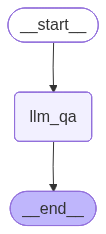

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())


In [22]:
#Execute
initial_state = {'question': 'How far is moon and star from earth ?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

content="The distance between the Earth and the Moon varies as both bodies follow elliptical orbits. At its closest point (called perigee), the Moon is approximately 363,300 kilometers (225,300 miles) away from the Earth.\n\nThe distance between the Earth and a star depends on which star you're referring to. Stars are massive balls of hot, glowing gas that are light-years away from us. A light-year is the distance light travels in one year, which is about 9.461 billion kilometers (5.88 billion miles).\n\nHere are some approximate distances to a few notable stars:\n\n1. **Proxima Centauri**: 4.24 light-years or about 40.14 trillion kilometers (24.95 trillion miles) away.\n2. **Alpha Centauri**: 4.37 light-years or about 41.19 trillion kilometers (25.58 trillion miles) away.\n3. **Sirius**: 8.61 light-years or about 81.27 trillion kilometers (50.5 trillion miles) away.\n4. **Betelgeuse**: 640 light-years or about 6.07 quintillion kilometers (3.78 quintillion miles) away.\n5. **Deneb**: 3